In [2]:
import numpy as np
import pandas as pd
import math
from scipy.integrate import quad
from scipy.linalg import solve
from tqdm import tqdm

# ── Parameters ────────────────────────────────────────────────────────────────
r             = 0.1
ACTION_START  = pd.Timestamp("2024-01-01")
ACTION_END    = pd.Timestamp("2025-12-31")
N_ACTION_DAYS = (ACTION_END - ACTION_START).days + 1  # 731

# ── Data ──────────────────────────────────────────────────────────────────────
F_C_full        = pd.read_csv("../data/THE_data_original.csv")
seasonal_params = pd.read_csv("../data/seasonal_params.csv")

a1_hat = float(seasonal_params["a1_hat"].iloc[0])
a2_hat = float(seasonal_params["a2_hat"].iloc[0])

for col in ["delivery_start", "delivery_end", "trading_date"]:
    F_C_full[col] = (
        pd.to_datetime(F_C_full[col], utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )

def parse_contract(row):
    ct, c = row["contract_type"], row["contract"]
    if ct == "month":
        return pd.to_datetime(f"01 {c}", format="%d %b %Y")
    if ct == "quarter":
        year, q = int(c[:4]), int(c[6])
        return pd.Timestamp(year=year, month=1 + 3*(q - 1), day=1)
    if ct == "year":
        return pd.Timestamp(year=int(c), month=1, day=1)
    raise ValueError(f"Unknown contract_type={ct!r}")

F_C_full["contract"] = F_C_full.apply(parse_contract, axis=1)
F_C_full = F_C_full.sort_values(["trading_date", "delivery_start"]).reset_index(drop=True)

def get_contracts_for_date(trading_date: pd.Timestamp) -> pd.DataFrame:
    sub = F_C_full[F_C_full["trading_date"] == trading_date]
    month_starts = set(sub.loc[sub["contract_type"] == "month", "delivery_start"])
    keep = (sub["contract_type"] == "month") | (
           (sub["contract_type"] == "quarter") & ~sub["delivery_start"].isin(month_starts))
    return sub[keep].sort_values("delivery_start").reset_index(drop=True)

# ── Seasonal component ────────────────────────────────────────────────────────
_WEEKEND_SPREAD = -0.35   # EUR/MWh
_WEEKDAY_SHIFT  = -_WEEKEND_SPREAD * (2.0 / 7.0)
_WEEKEND_SHIFT  = _WEEKDAY_SHIFT + _WEEKEND_SPREAD

def s(tau, origin: pd.Timestamp):
    """
    Seasonal price component at year-fraction tau measured from origin.
    Annual sinusoidal term plus a flat weekday/weekend spread.
    Uses integer modular arithmetic to avoid pandas overhead on scalar calls.
    """
    tau      = np.atleast_1d(np.asarray(tau, dtype=float))
    days     = np.floor(tau * 365.0 + 1e-12).astype(int)
    weekdays = (origin.weekday() + days) % 7
    spread   = np.where(weekdays >= 5, _WEEKEND_SHIFT, _WEEKDAY_SHIFT).astype(float)
    result   = np.exp(a1_hat * np.sin(2*np.pi*tau) + a2_hat * np.cos(2*np.pi*tau)) + spread
    return float(result[0]) if result.size == 1 else result

# ── Forward curve helpers ─────────────────────────────────────────────────────
def _w(u: float, T_s: float, T_e: float) -> float:
    """Normalised PV weight: integrates to 1 over [T_s, T_e]."""
    return np.exp(-r * u) / ((np.exp(-r * T_s) - np.exp(-r * T_e)) / r)

def _phi(tau: float) -> tuple:
    """C0, C1, C2 basis vectors at tau for a degree-4 polynomial."""
    return (
        np.array([tau**4, tau**3, tau**2, tau, 1.0]),
        np.array([4*tau**3, 3*tau**2, 2*tau, 1.0, 0.0]),
        np.array([12*tau**2, 6*tau, 2.0, 0.0, 0.0]),
    )

def _day_breakpoints(T_s: float, T_e: float) -> list:
    """Interior day-boundary points in (T_s, T_e) — discontinuities of s(u)."""
    lo = math.ceil(T_s * 365.0 + 1e-9)
    hi = math.floor(T_e * 365.0 - 1e-9)
    return [k / 365.0 for k in range(lo, hi + 1)]

# ── Forward curve construction ────────────────────────────────────────────────
def construct_forward_curve(trading_date: pd.Timestamp) -> tuple:
    F_C = get_contracts_for_date(trading_date).copy()
    F_C["T_s"] = (F_C["delivery_start"] - trading_date).dt.days / 365.0
    F_C["T_e"] = (F_C["delivery_end"]   - trading_date).dt.days / 365.0

    t     = np.r_[F_C["T_s"].to_numpy(), F_C["T_e"].iloc[-1]]
    n     = len(t) - 1
    Delta = np.diff(t)

    # Hessian (smoothness penalty on epsilon\'\')
    H = np.zeros((5*n, 5*n))
    for j in range(n):
        Dj = Delta[j]; sl = slice(5*j, 5*j+5)
        H[sl, sl] = np.array([
            [(144/5)*Dj**5, 18*Dj**4, 8*Dj**3, 0, 0],
            [18*Dj**4,      12*Dj**3, 6*Dj**2, 0, 0],
            [8*Dj**3,        6*Dj**2, 4*Dj,    0, 0],
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
        ])

    # Constraint matrix
    num_constraints = 3*(n - 1) + n + 2
    A = np.zeros((num_constraints, 5*n))
    b = np.zeros(num_constraints)
    row = 0

    # C0/C1/C2 continuity at interior knots
    for j in range(n - 1):
        p0, p1, p2 = _phi(t[j + 1])
        sl, sr = slice(5*j, 5*j+5), slice(5*j+5, 5*j+10)
        A[row,   sl] = -p0;  A[row,   sr] = p0
        A[row+1, sl] = -p1;  A[row+1, sr] = p1
        A[row+2, sl] = -p2;  A[row+2, sr] = p2
        row += 3

    # Contract-consistency: weighted average of epsilon matches price minus seasonal shift
    for i in range(n):
        T_s, T_e = t[i], t[i + 1]
        bpts = _day_breakpoints(T_s, T_e)
        kw   = {"points": bpts, "limit": len(bpts) + 50} if bpts else {}
        A[row, 5*i:5*i+5] = [
            quad(lambda u, p=p: _w(u, T_s, T_e) * u**p, T_s, T_e)[0]
            for p in range(4, -1, -1)
        ]
        b[row] = (
            float(F_C["price"].iloc[i])
            - quad(lambda u: _w(u, T_s, T_e) * s(u, trading_date), T_s, T_e, **kw)[0]
        )
        row += 1

    # Boundary: epsilon\'(t_n) = 0
    _, p1_n, _ = _phi(t[n])
    A[row, 5*(n-1):5*n] = p1_n; row += 1

    # Initial condition: pin epsilon at the first knot
    p0_0, _, _ = _phi(t[0])
    A[row, :5] = p0_0
    b[row]     = float(F_C["price"].iloc[0]) - s(t[0], trading_date)

    # KKT solve
    KKT = np.block([[2*H, A.T], [A, np.zeros((num_constraints, num_constraints))]])
    x   = solve(KKT, np.r_[np.zeros(5*n), b], assume_a="sym")[:5*n]

    # Evaluate on daily grid (vectorised per segment using np.polyval)
    n_days  = int(round(F_C["T_e"].iloc[-1] * 365))
    t_eval  = np.arange(n_days + 1) / 365.0
    j_idx   = np.clip(np.searchsorted(t, t_eval, side="right") - 1, 0, n - 1)
    epsilon = np.empty(len(t_eval))
    for j in range(n):
        mask = j_idx == j
        if mask.any():
            epsilon[mask] = np.polyval(x[5*j:5*j+5], t_eval[mask])

    return (
        pd.date_range(start=trading_date, periods=len(t_eval), freq="D"),
        epsilon + s(t_eval, trading_date),
    )

# ── Build forward-price surface ───────────────────────────────────────────────
action_dates      = pd.date_range(ACTION_START, ACTION_END, freq="D")
all_trading_dates = pd.to_datetime(np.sort(F_C_full["trading_date"].unique()))
# Keep only dates within the action period, plus the last one before it
# (needed to serve action days before the first in-period trading date).
_pre = all_trading_dates[all_trading_dates < ACTION_START]
all_trading_dates = all_trading_dates[
    (all_trading_dates >= (_pre[-1] if len(_pre) else ACTION_START)) &
    (all_trading_dates <= ACTION_END)
]
del _pre

print("Building forward curve cache ...")
curve_cache: dict = {}
supported_month_starts: dict = {}
for td in tqdm(all_trading_dates):
    fwd_dates, fwd_prices = construct_forward_curve(td)
    curve_cache[td] = dict(zip(fwd_dates.normalize(), fwd_prices.tolist()))
    supported_month_starts[td] = set(
        get_contracts_for_date(td)
        .loc[lambda df: df["contract_type"] == "month", "delivery_start"]
        .dt.normalize()
    )

# surface[i, j] = forward price for action day j seen from action day i
# Only the upper triangle (j >= i) is populated and used by the DP.
# Within the unsupported front-gap after the monthly roll, freeze to the
# last trading date that still lists the action day's current month.
print("Filling forward-price surface ...")
surface = np.full((N_ACTION_DAYS, N_ACTION_DAYS), np.nan)

for i, action_day in enumerate(tqdm(action_dates)):
    candidates = all_trading_dates[all_trading_dates <= action_day]
    if len(candidates) == 0:
        raise ValueError(f"No trading date on or before {action_day.date()}")
    current_month_start = action_day.replace(day=1).normalize()
    supported_candidates = [
        td for td in candidates
        if current_month_start in supported_month_starts[td]
    ]
    curve_date = supported_candidates[-1] if supported_candidates else candidates[-1]
    fwd_dict = curve_cache[curve_date]
    for j in range(i, N_ACTION_DAYS):
        surface[i, j] = fwd_dict.get(action_dates[j], np.nan)

Building forward curve cache ...


100%|██████████| 503/503 [01:24<00:00,  5.93it/s]


Filling forward-price surface ...


100%|██████████| 731/731 [00:00<00:00, 1289.55it/s]


In [3]:
import numba as nb
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

# ----------------------------
# Build all-calendar-day date grid (Jan 2 2024 – Dec 31 2025)
# ----------------------------
DATE_START = pd.Timestamp("2024-01-01")

data = pd.DataFrame({"date": pd.date_range("2024-01-02", "2025-12-31", freq="D")})
data["t"] = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data = data.sort_values("date").reset_index(drop=True)

Tn    = len(data)
t_arr = data["t"].to_numpy()

# Calendar-day index of each day (0 = DATE_START = Jan 1 2024)
cal_idx = (data["date"] - DATE_START).dt.days.to_numpy(dtype=np.int64)

# ============================================================
# MODEL PARAMETERS
# ============================================================
alpha_c          = 10_000.0
refine_factor    = 4
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
terminal_penalty = -np.inf

# Step-varying discount: accounts for multi-day gaps
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 10_125_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 3_780.0 * 24.0
WDRMAX_BASE    = 7_500.0 * 24.0

# ---------- vmin: technical-feasibility floor from dated anchors ----------
VMIN_BASE = 0.0
_VMIN_CYCLE_START  = pd.Timestamp("2024-01-01")
_VMIN_CYCLE_LENGTH = 365 + 366

_VMIN_ANCHOR_DATES = pd.DatetimeIndex(pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
]))
_VMIN_ANCHOR_VALUES = VMAX_CONST * np.array([
    0.45, 0.40, 0.60, 0.80, 0.90,
    0.45, 0.40, 0.60, 0.75, 0.90,
], dtype=np.float64)
_VMIN_ANCHOR_X = (_VMIN_ANCHOR_DATES - _VMIN_CYCLE_START).days.to_numpy()
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
_VMIN_ANCHOR_X_ALL = np.r_[
    _VMIN_ANCHOR_X - _VMIN_CYCLE_LENGTH,
    _VMIN_ANCHOR_X,
    _VMIN_ANCHOR_X + _VMIN_CYCLE_LENGTH,
]
_VMIN_ANCHOR_Y_ALL = np.r_[
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
    _VMIN_ANCHOR_VALUES,
]

def feasible_vmin_for_dates(dates_like) -> np.ndarray:
    dates = pd.DatetimeIndex(dates_like)
    date_x = (dates - _VMIN_CYCLE_START).days.to_numpy()
    feasible_floor = np.empty(len(dates), dtype=np.float64)
    inj_max = INJECTMAX_BASE
    wdr_max = WDRMAX_BASE
    for i, t in enumerate(date_x):
        future_mask = _VMIN_ANCHOR_X_ALL >= t
        past_mask   = _VMIN_ANCHOR_X_ALL <= t

        days_to_future = _VMIN_ANCHOR_X_ALL[future_mask] - t
        days_from_past = t - _VMIN_ANCHOR_X_ALL[past_mask]

        required_for_future = (
            _VMIN_ANCHOR_Y_ALL[future_mask] - inj_max * days_to_future
        ).max()
        required_from_past = (
            _VMIN_ANCHOR_Y_ALL[past_mask] - wdr_max * days_from_past
        ).max()

        feasible_floor[i] = np.clip(
            max(required_for_future, required_from_past),
            VMIN_BASE,
            VMAX_CONST,
        )
    return feasible_floor

def vmin_at_date(date: pd.Timestamp) -> float:
    return float(feasible_vmin_for_dates(pd.DatetimeIndex([date]))[0])

def inj_cap(fill_frac: float) -> float:
    return (0.75 if fill_frac >= 0.95 else 1.00) * INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    if   fill_frac <= 0.05:  cap = 0.25
    elif fill_frac <= 0.125: cap = 0.50
    elif fill_frac <= 0.15:  cap = 0.75
    elif fill_frac <= 0.20:  cap = 0.85
    else:                    cap = 1.00
    return cap * WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = feasible_vmin_for_dates(dates_pd)

# v0 and vT_target: fixed level, snapped to fine grid
v_target_raw = 9_153_925.0
v0        = round(v_target_raw / alpha_f) * alpha_f
vT_target = round(v_target_raw / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vT_target = {vT_target:>12,.0f}  (snapped from {v_target_raw:,.0f})")
print(f"vmax range: {vmax_arr.min():,.0f} - {vmax_arr.max():,.0f}")
print(f"vmin range: {vmin_arr.min():,.0f} - {vmin_arr.max():,.0f}")

# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets -- one per day step
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets ...")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

print("Done.")

# ============================================================
# Numba kernel: one deterministic Bellman step
# ============================================================

@nb.njit(fastmath=True)
def bellman_intrinsic(Y_current, pi_row, F_t, Y_disc,
                      next_idx_mat, dv_mat, K_len, terminal_penalty):
    Nf = next_idx_mat.shape[0]
    for n_f in range(Nf):
        klen = K_len[n_f]
        if klen == 0:
            Y_current[n_f] = terminal_penalty
            pi_row[n_f]    = -1
            continue
        best_val  = terminal_penalty
        best_next = -1
        for k in range(klen):
            nxt  = next_idx_mat[n_f, k]
            dv   = dv_mat[n_f, k]
            cand = (-F_t * dv) + Y_disc[nxt]
            if cand > best_val:
                best_val  = cand
                best_next = nxt
        Y_current[n_f] = best_val
        pi_row[n_f]    = best_next

# ============================================================
# Rolling intrinsic DP
#
# For each calendar day i (i = 0 ... T-1):
#   1. Read the forward prices for all remaining days from surface row cal_idx[i].
#   2. Run backward DP from step T-1 down to step i, recording only the
#      first-step policy pi_first.
#   3. Execute the first-step decision from the current state.
#   4. Advance to day i+1.
#
# Disc is applied once per day step (flat 1/365 convention,
# consistent with intrinsic_valuation_GSD.ipynb).
# ============================================================
T = Tn - 1   # number of steps

n_curr      = n0_f
decisions   = np.zeros(T, dtype=np.float64)
daily_pnl   = np.zeros(T, dtype=np.float64)
volume_path = np.empty(T + 1, dtype=np.float64)
volume_path[0] = v_fine[n0_f]

pi_first  = np.full(Nf, -1, dtype=np.int32)
pi_dummy  = np.full(Nf, -1, dtype=np.int32)
Y_current = np.empty(Nf, dtype=np.float64)

print("Running rolling intrinsic DP ...")
for i in tqdm(range(T)):
    cal_i = int(cal_idx[i])

    # Backward DP: step t from T-1 down to i
    # Y_next starts as the terminal value (volume must equal vT_target after step T-1)
    Y_next = terminal_value(v_fine)

    for t in range(T - 1, i - 1, -1):
        F_t    = float(surface[cal_i, int(cal_idx[t])])
        Y_disc = disc_arr[t] * Y_next
        pi_row = pi_first if t == i else pi_dummy
        bellman_intrinsic(
            Y_current, pi_row, F_t, Y_disc,
            all_next_idx[t], all_dv_mat[t], all_K_len[t],
            terminal_penalty,
        )
        Y_next, Y_current = Y_current, Y_next

    # Execute first-step decision from current state
    n_next = int(pi_first[n_curr])
    if n_next < 0:
        raise RuntimeError(
            f"No feasible action on day {i} "
            f"({data['date'].iloc[i].date()}) from state index n={n_curr}."
        )

    dv        = v_fine[n_next] - v_fine[n_curr]
    F_today   = float(surface[cal_i, cal_i])   # diagonal = today's forward price
    cash_flow = -F_today * dv

    decisions[i]       = dv
    daily_pnl[i]       = cash_flow
    volume_path[i + 1] = v_fine[n_next]
    n_curr             = n_next

total_value = float(np.sum(daily_pnl))
print(f"\nRolling intrinsic value : {total_value:,.2f}")
print(f"Final volume            : {v_fine[n_curr]:>15,.0f}  (target: {vT_target:,.0f})")

v0        =    9,155,000  (snapped from 9,153,925)
vT_target =    9,155,000  (snapped from 9,153,925)
vmax range: 10,125,000 - 10,125,000
vmin range: 0 - 9,112,500

Grid: Nc=1013, Nf=4049, n0_f=3662, nT_f=3662
Pre-computing feasible action sets ...
Done.
Running rolling intrinsic DP ...


100%|██████████| 729/729 [00:59<00:00, 12.16it/s]


Rolling intrinsic value : 111,434,029.06
Final volume            :       9,155,000  (target: 9,155,000)


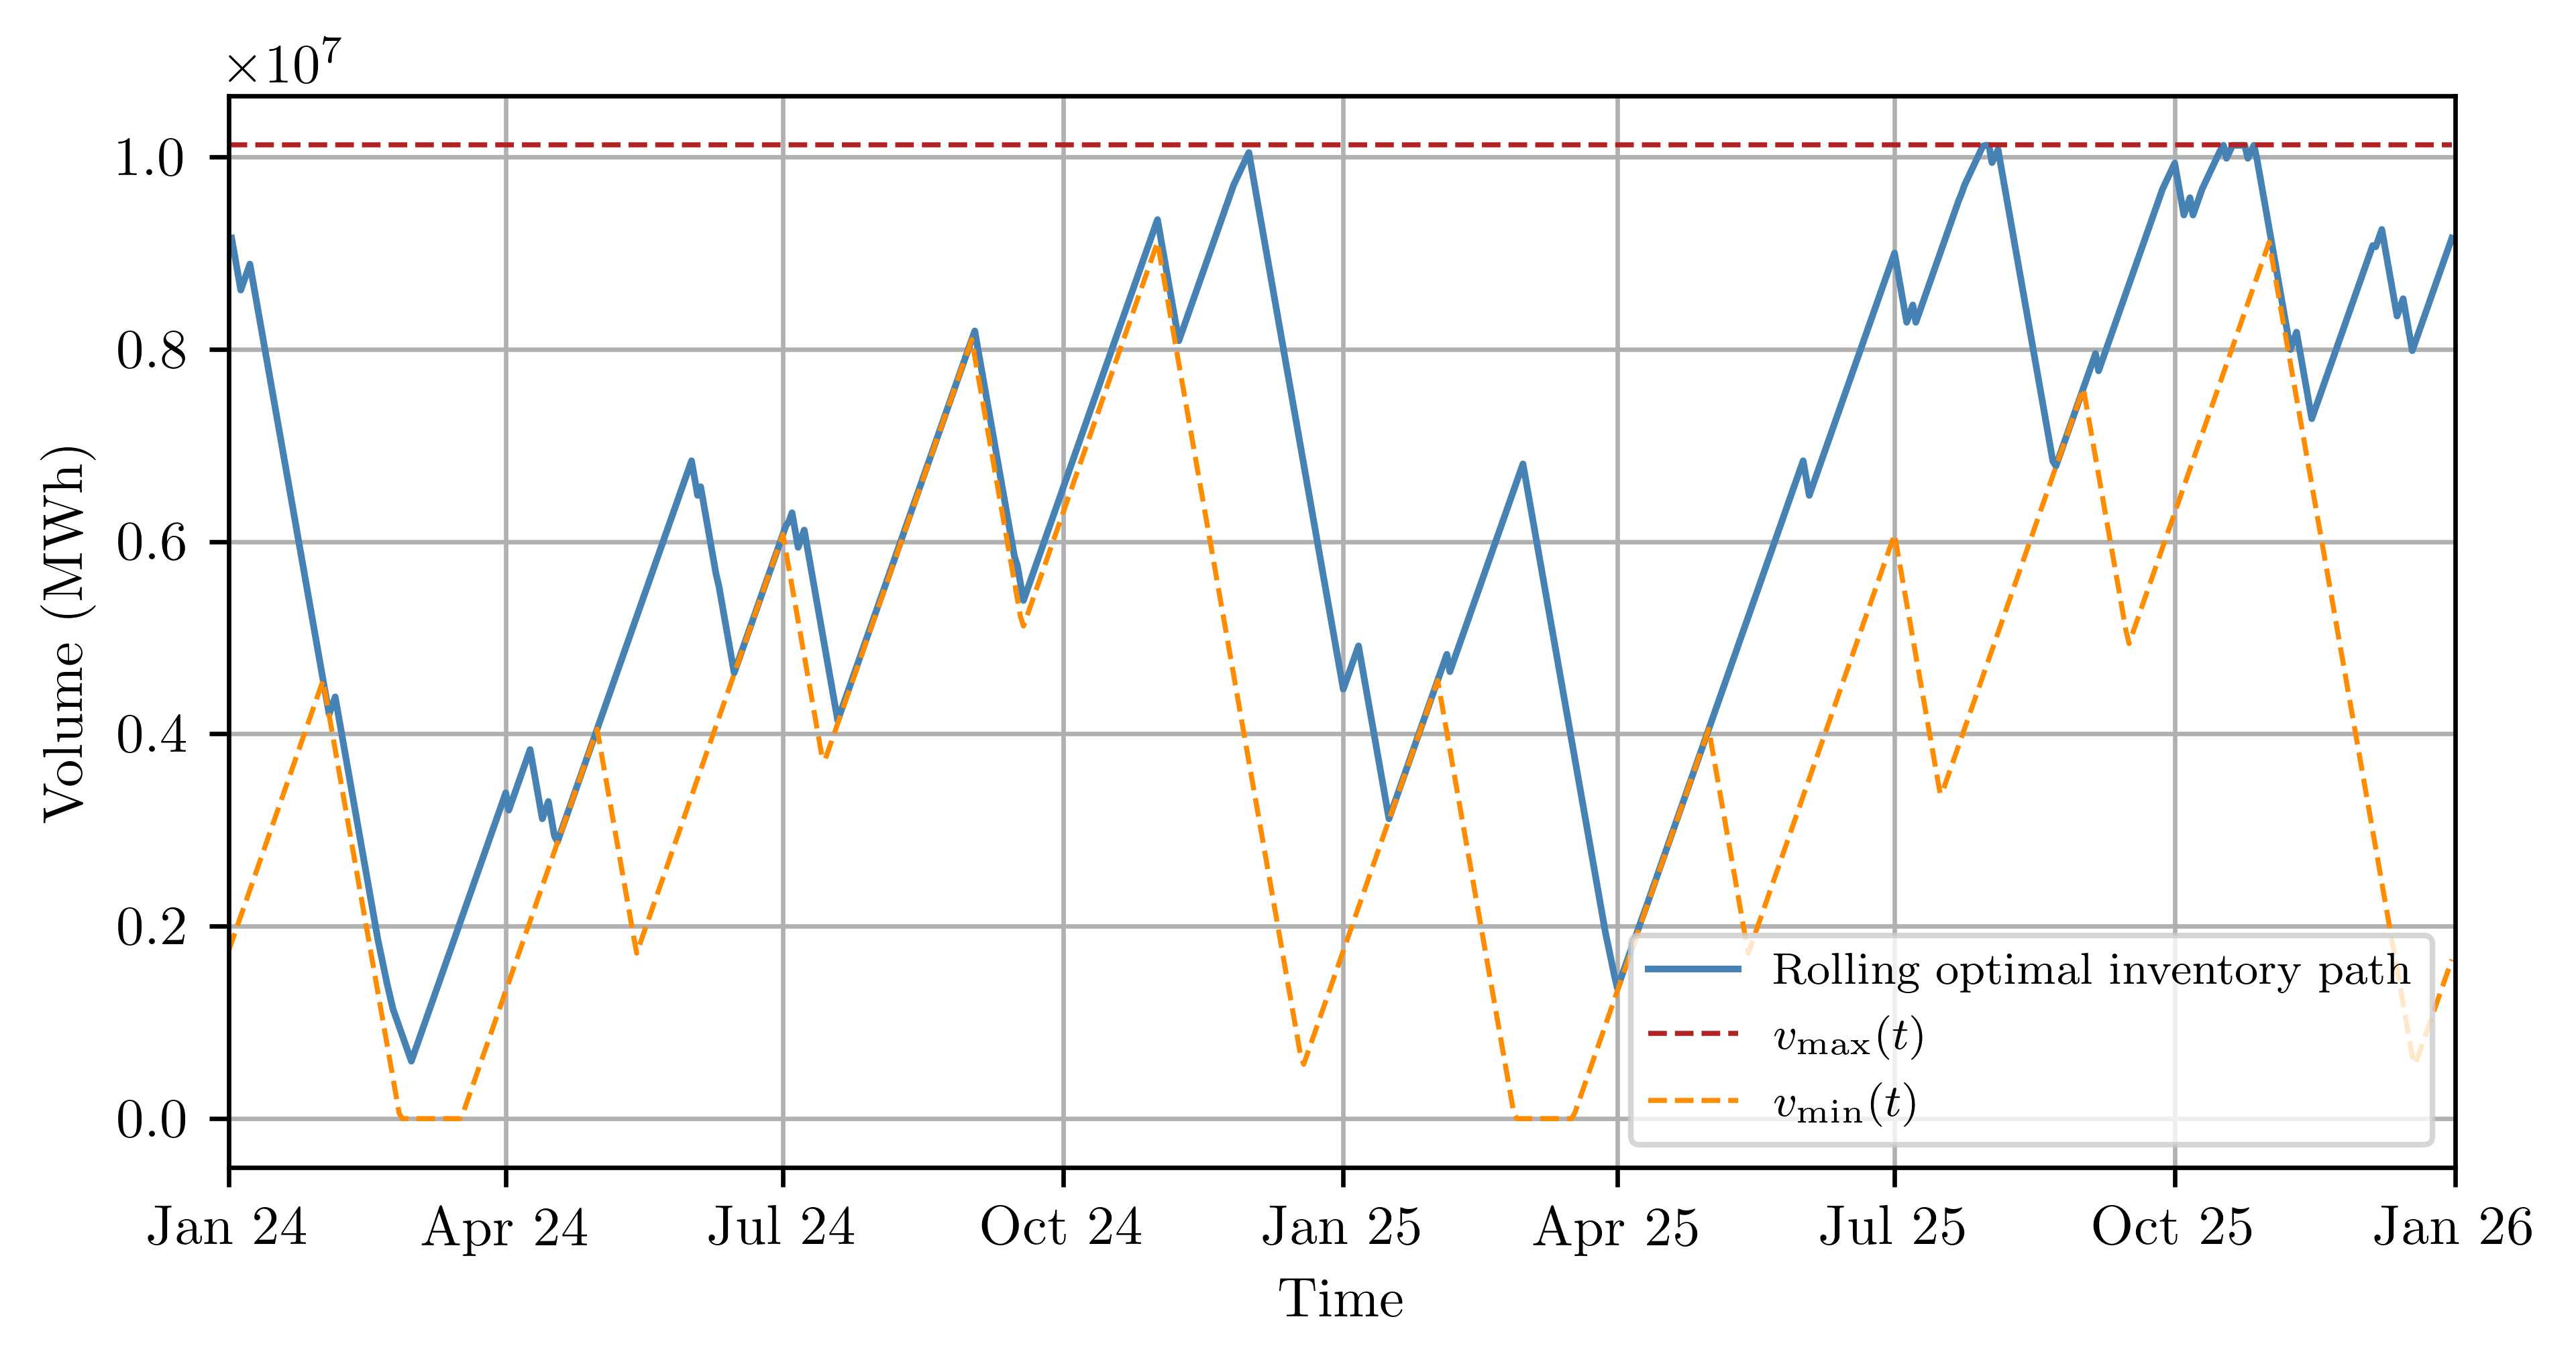

In [4]:
from matplotlib import dates


mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

x_start        = pd.Timestamp("2024-01-01")
x_end          = pd.Timestamp("2025-12-31")
constraint_end = pd.Timestamp("2025-12-31")

# Dense daily grid for constraint curves
dense_dates = pd.date_range(start=x_start, end=constraint_end, freq="D")
vmax_dense  = np.full(len(dense_dates), VMAX_CONST, dtype=np.float64)
vmin_dense  = feasible_vmin_for_dates(dense_dates)

# Trading-day dates for volume path (T+1 = 511 entries: days 0 ... T)
dates_plot = pd.DatetimeIndex(data["date"].to_numpy())

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Rolling optimal volume path (one point per trading day)
ax.plot(dates_plot, volume_path, color="steelblue", lw=1.2,
        label="Rolling optimal inventory path")

# Constraint curves (dense daily grid)
ax.step(dense_dates, vmax_dense, where="post", color="firebrick",
        lw=0.9, ls="--", label=r"$v_{\max}(t)$")
ax.plot(dense_dates, vmin_dense, color="darkorange",
        lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/rolling_intrinsic_valuation_optimal_path_GSD.png")
plt.show()


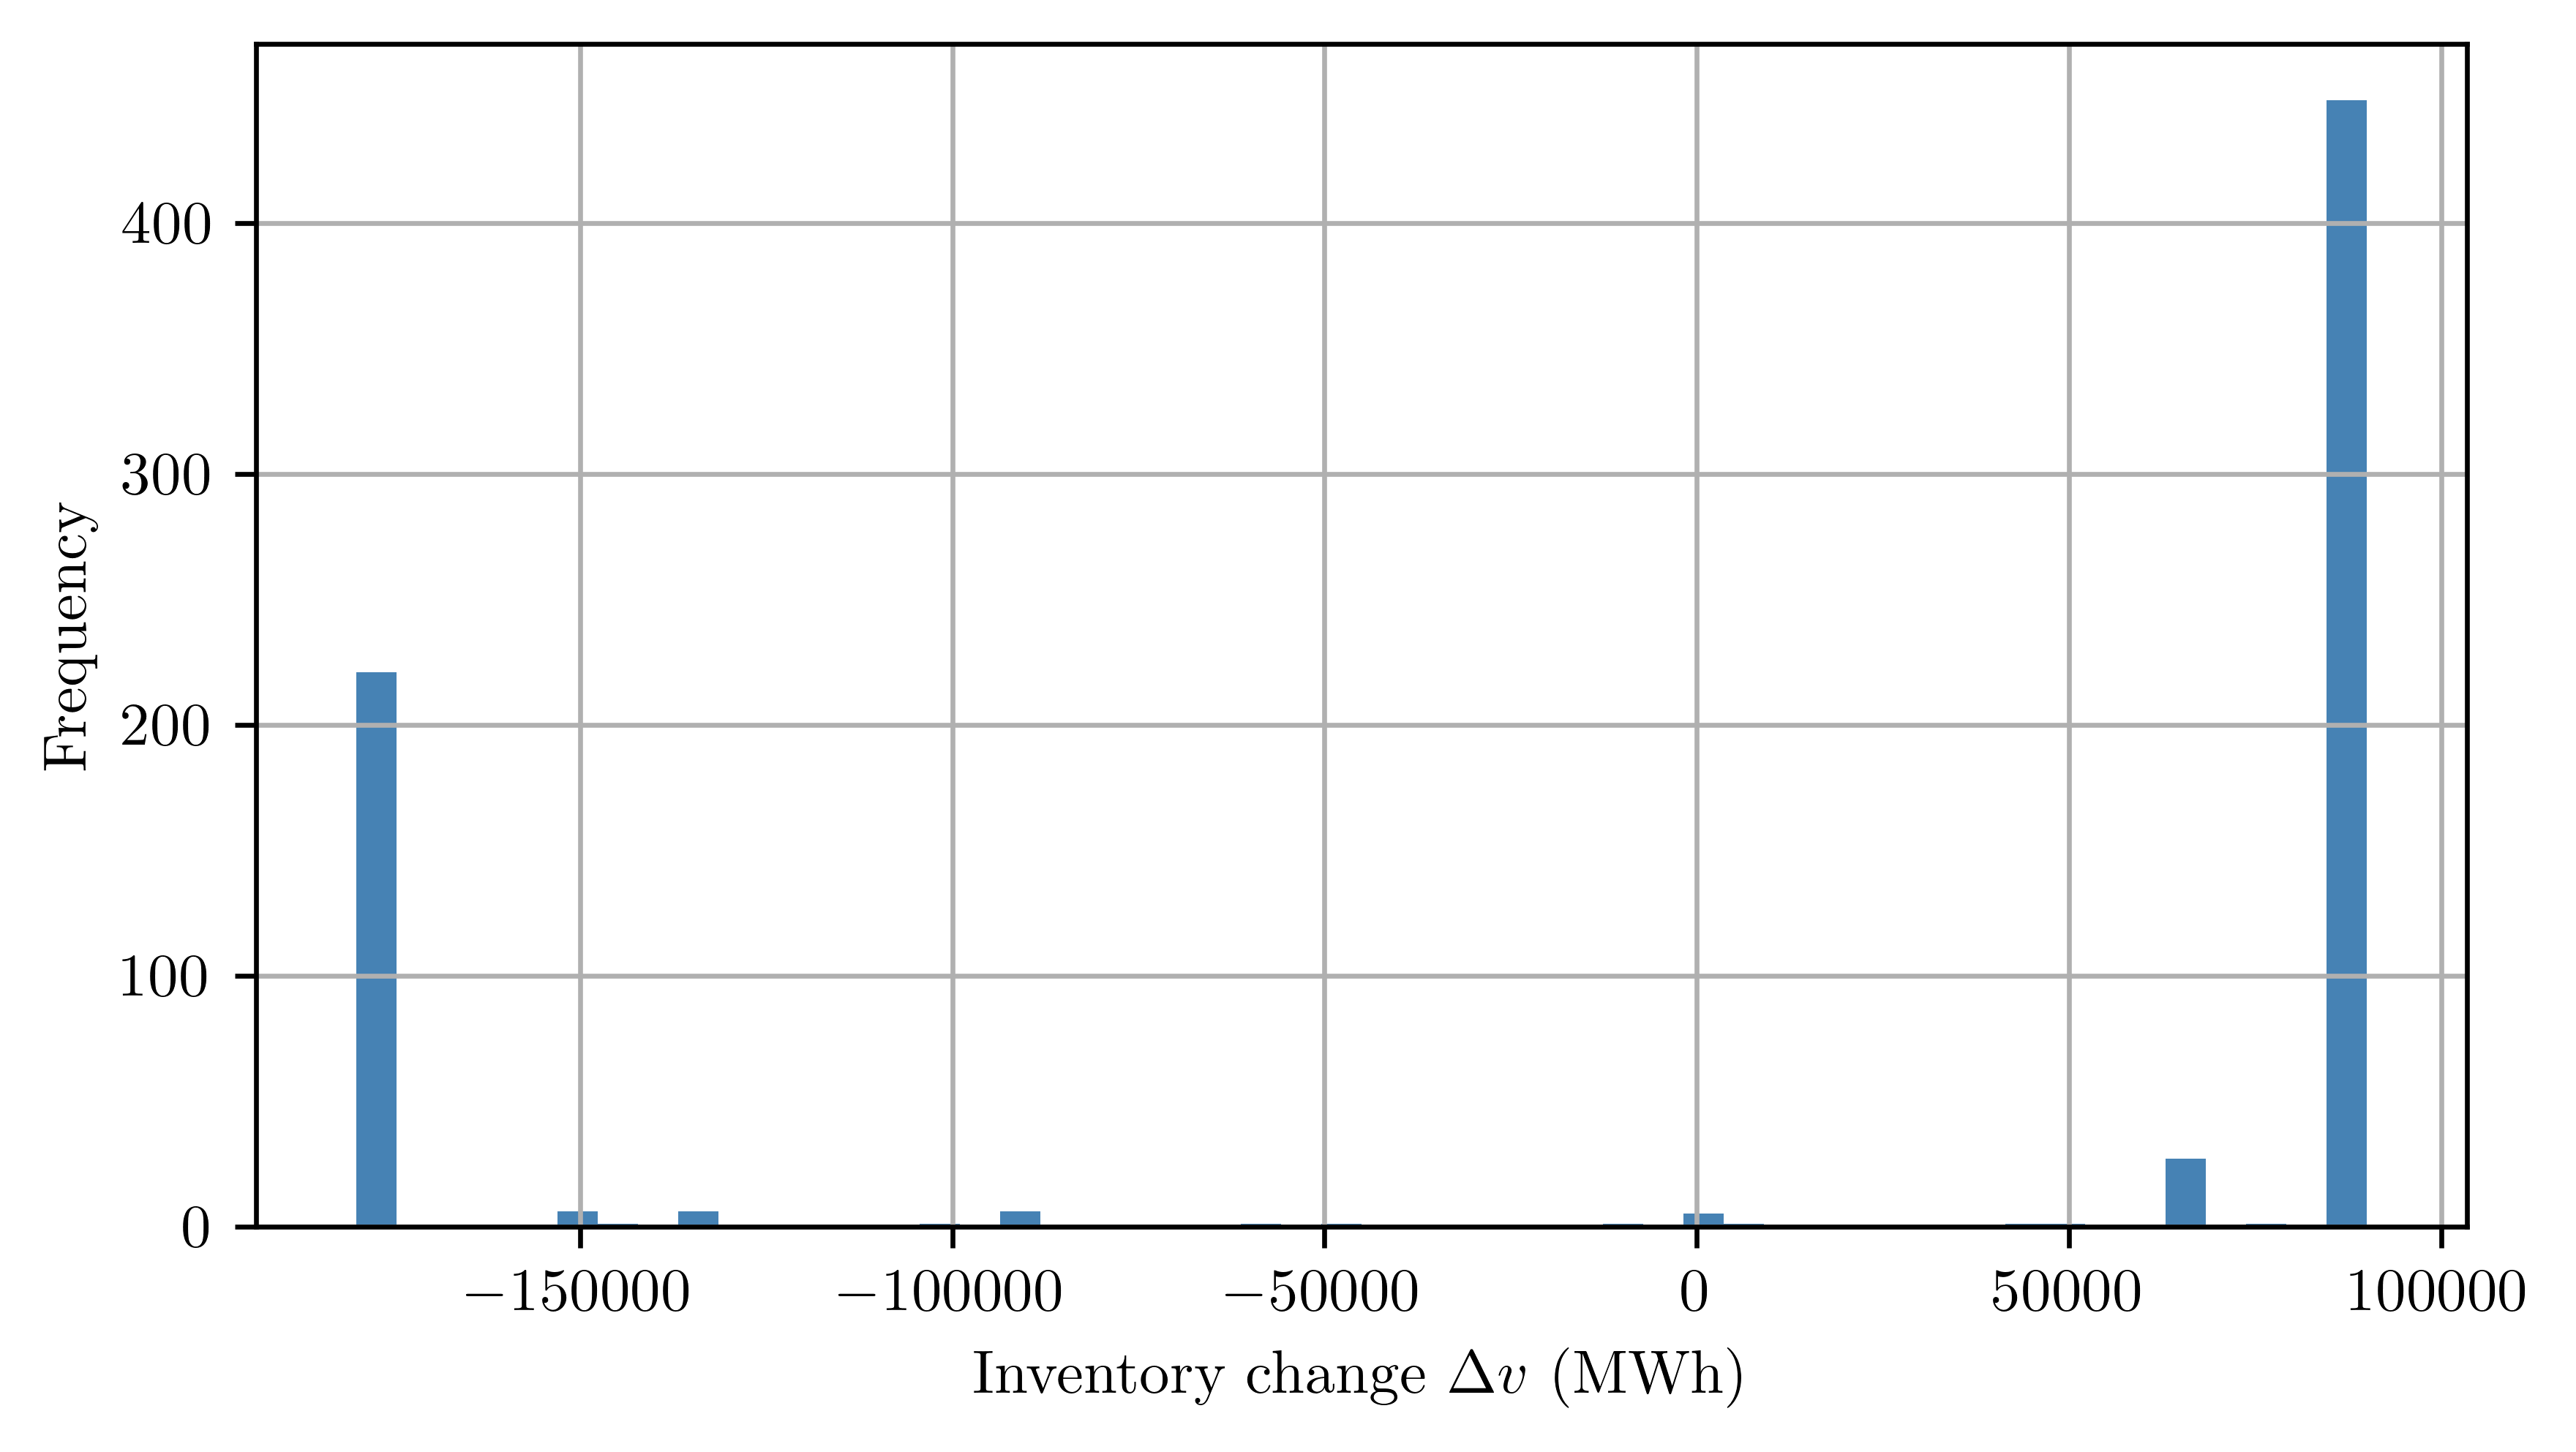

In [6]:
# Load realised_paths_OLS_GSD.npz
delta_v_path = np.diff(volume_path, axis=0)

# Print a inventory change frequency histogram
plt.figure(figsize=(6.5, 3.5), dpi=600)
plt.hist(delta_v_path.flatten(), bins=50, alpha=1, color = "steelblue")
plt.xlabel("Inventory change $\\Delta v$ (MWh)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("../../fig/Plots/rolling_intrinsic_valuation_inventory_change_distribution_GSD.png")
plt.show()

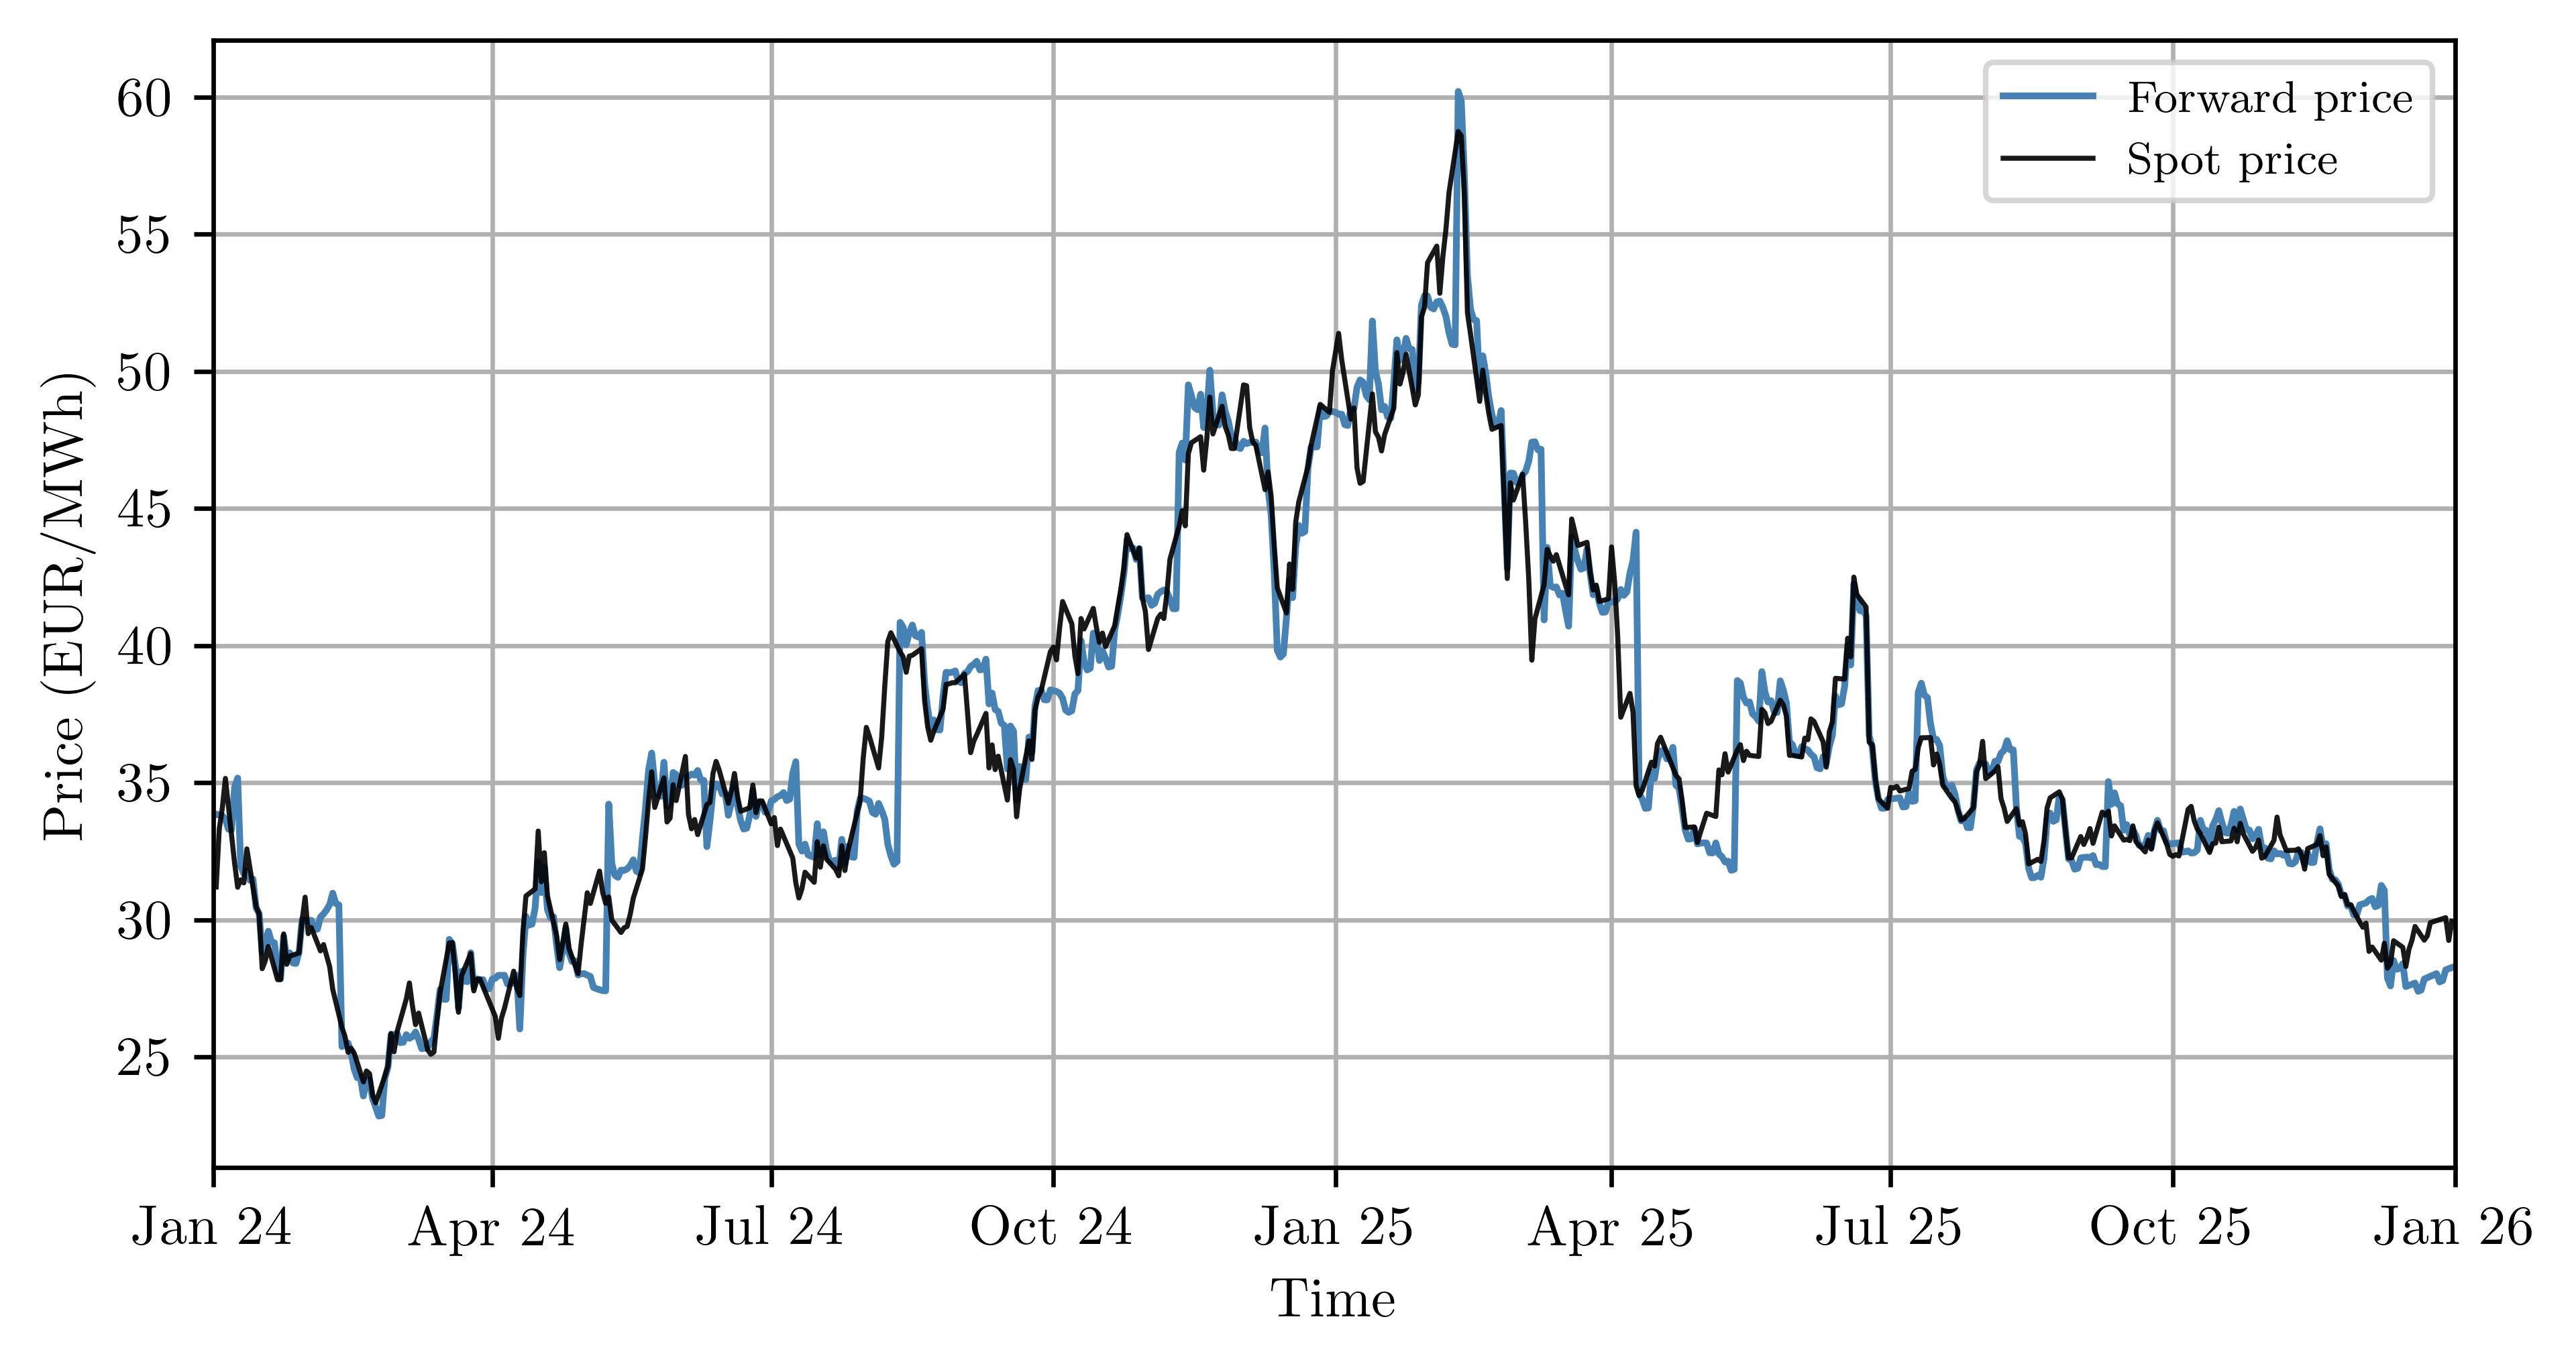

In [8]:
# Daily forward price used as time progresses: for each calendar day t,
# use the latest available trading date on or before t.
import re

forward_price_series = pd.Series(
    np.diag(surface),
    index=action_dates,
    name="forward_price",
)

with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

spot_data = pd.DataFrame({
    "date": pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

spot_obs = (
    spot_data
    .dropna(subset=["spot_price"])
    .loc[
        (spot_data["date"] >= "2024-01-02")
        & (spot_data["date"] <= "2025-12-31")
    ]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)
ax.plot(forward_price_series.index, forward_price_series.values,
        color="steelblue", lw=1.2, label="Forward price")
ax.plot(spot_obs["date"], spot_obs["spot_price"],
        color="black", lw=0.9, alpha=0.9, label="Spot price")

ax.set_xlabel("Time")
ax.set_ylabel("Price (EUR/MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=ACTION_START, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(ACTION_START, ACTION_END)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()
